# Phần 3: Biến đổi hình học (Transformations)

Notebook này dùng các hàm biến đổi đã viết trong `transform.py` để trực quan hóa:
- Translation, rotation, scaling
- Affine transformation
- Projective (homography) transformation

và so sánh sự khác nhau giữa affine và projective transformation.

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())
from transform import translate, rotate, scale_image, affine_transform, projective_transform

IMAGE_PATH = os.path.join(os.getcwd(), "..", "..", "images", "strawberry.jpg")

img_bgr = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
print("Image size:", img.shape)

Image size: (350, 642, 3)


## 3.1 Translation, Rotation, Scaling

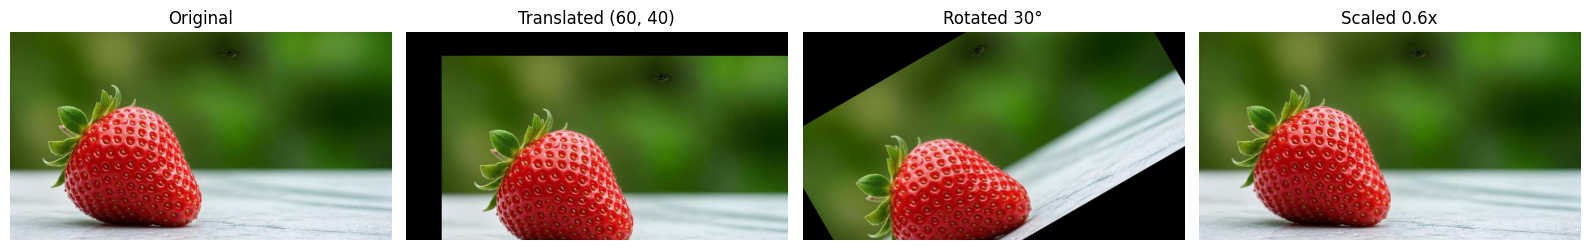

In [2]:
translated = cv2.cvtColor(translate(img_bgr, tx=60, ty=40), cv2.COLOR_BGR2RGB)
rotated = cv2.cvtColor(rotate(img_bgr, angle=30), cv2.COLOR_BGR2RGB)
scaled = cv2.cvtColor(scale_image(img_bgr, fx=0.6, fy=0.6), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original", "Translated (60, 40)", "Rotated 30\u00b0", "Scaled 0.6x"]
images = [img, translated, rotated, scaled]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.2 Affine vs Projective Transformation

- **Affine transformation** dùng 3 cặp điểm tương ứng. Phép biến đổi này bảo toàn tính **song song** của các đường thẳng (translation, rotation, scaling, shear đều là trường hợp đặc biệt của affine).
- **Projective (homography) transformation** dùng 4 cặp điểm tương ứng, không bảo toàn tính song song — cho phép mô phỏng hiệu ứng phối cảnh (nhìn một mặt phẳng từ góc nghiêng), ví dụ như ảnh chụp một tờ giấy bị nghiêng camera.

Để thấy rõ sự khác biệt, ta vẽ khung biên của ảnh gốc (một hình chữ nhật) rồi xem nó biến thành hình gì sau mỗi phép biến đổi.

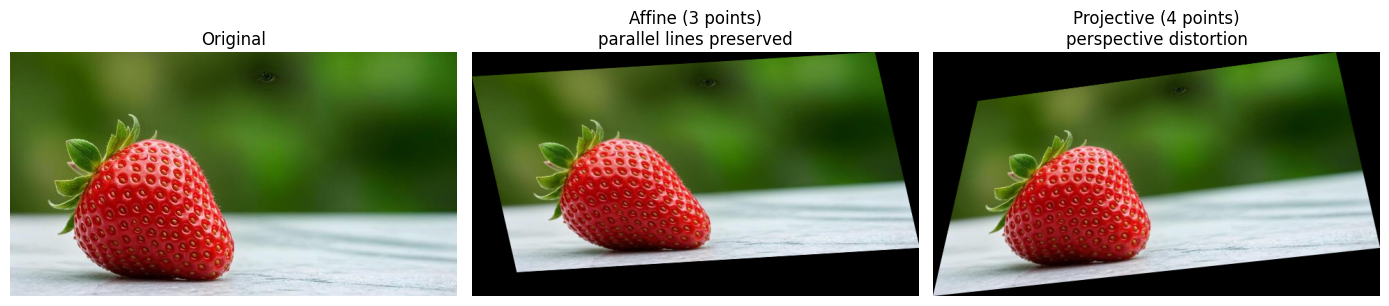

In [3]:
affine_src = [[0, 0], [w - 1, 0], [0, h - 1]]
affine_dst = [[0, h * 0.1], [w * 0.9, 0], [w * 0.1, h * 0.9]]
affine_result = cv2.cvtColor(affine_transform(img_bgr, affine_src, affine_dst), cv2.COLOR_BGR2RGB)

proj_src = [[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]]
proj_dst = [[w * 0.1, h * 0.2], [w * 0.9, 0], [0, h - 1], [w - 1, h * 0.8]]
projective_result = cv2.cvtColor(projective_transform(img_bgr, proj_src, proj_dst), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(affine_result)
axes[1].set_title("Affine (3 points)\nparallel lines preserved")
axes[2].imshow(projective_result)
axes[2].set_title("Projective (4 points)\nperspective distortion")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Nhận xét

- **Translation / Rotation / Scaling**: là các phép biến đổi affine đặc biệt, chỉ thay đổi vị trí, góc xoay hoặc kích thước nhưng giữ nguyên hình dạng (shape) của vật thể.
- **Affine transformation** (tổng quát hơn, dùng 3 điểm): có thể biểu diễn translation + rotation + scaling + shear cùng lúc. Các đường thẳng song song trong ảnh gốc **vẫn song song** sau biến đổi — ảnh kết quả có dạng hình bình hành (parallelogram).
- **Projective transformation** (dùng 4 điểm, ma trận homography 3x3): tổng quát hơn affine, mô phỏng được góc nhìn phối cảnh (perspective). Các đường thẳng song song **có thể hội tụ** sau biến đổi — ảnh kết quả có thể là một tứ giác bất kỳ (không nhất thiết là hình bình hành).

**Trường hợp sử dụng:**
- Affine: căn chỉnh ảnh khi biết camera chỉ di chuyển song song với mặt phẳng ảnh (không có phối cảnh), augment dữ liệu (xoay, lật, scale) cho huấn luyện model.
- Projective: chỉnh sửa ảnh chụp bị nghiêng góc (document scanning, bird's-eye view cho ảnh đường, ghép ảnh panorama).

**Hạn chế:** cả hai đều là phép biến đổi 2D-2D dựa trên một mặt phẳng; không mô hình hóa được độ sâu (depth) thực sự của cảnh 3D, nên nếu vật thể trong ảnh không phẳng (có độ sâu khác nhau), kết quả biến đổi sẽ bị méo không chính xác.